In [ ]:
from utils import * 
import subprocess
import json 
from scipy.spatial.distance import pdist, cdist
# from scipy.spatial.distance import pdist, squareform
import toytree
import glob

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
FIGURE_DIR = os.path.abspath('./figures/analysis-1-cluster_3')
os.makedirs(FIGURE_DIR, exist_ok=True)

ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_3' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.

In [ ]:
get_num_subunits = lambda name : int(re.search(r'(\d+)mer', name).group(1))

In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id != 'bz_12')].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_3.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3.faa -output ../data/genes/cluster_3.afa', shell=True, check=True)

In [22]:
ATPASE_DOMAIN_COORDS = (24, 215) # Relative to the Betazoid cluster_3 MSA. This is 
msa = MSA.from_file(path='../data/genes/cluster_3.afa')

# Use the MSA to determine the ATPase domain coordinates for each sequence, even those lacking an annotation. 
for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'atpase_domain_start'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'atpase_domain_stop'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[1], gene_id)

In [23]:
# (1) Downloaded all bacterial (reviewed), archaeal (reviewed), and viral (all) sequences annotated as SSF52540 (P-loop ATPase) from UniProt. 
# (2) Constructed a BLAST database with the downloaded sequences to find those which are the best match. 
#   makeblastdb -in uniprot_supfam_SSF52540.faa -out ./blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -dbtype prot
# (3) BLAST-aligned the cluster_3 sequences against the database. 
#   blastp -db ../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -out ../data/genes/blast/cluster_3-blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540.tsv -query ../data/genes/cluster_3.faa -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 5000
# (4) Clustered the sequences at 80% identity using mmseqs. 
#   mmseqs easy-cluster uniprot_supfam_SSF52540_reviewed.faa ./mmseqs/uniprot_supfam_SSF52540_reviewed tmp --min-seq-id 0.9
# (5) Run InterProScan on the cluster representatives and extract the ATPase domains. 

MIN_PERCENT_IDENTITY = 20
MIN_ALIGNMENT_LENGTH = 100

BLASTP_DATABASE_PATH = '../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540'
BLASTP_QUERY_PATH = '../data/genes/cluster_3.faa'
BLASTP_OUTPUT_PATH = '../data/genes/blast/cluster_3-uniprot_supfam_SSF52540.tsv'
BLASTP_FIELDS = 'qseqid sseqid pident length evalue bitscore qstart qend sstart send sseq'

cmd = f'blastp -db {BLASTP_DATABASE_PATH} -out {BLASTP_OUTPUT_PATH} -query {BLASTP_QUERY_PATH} -outfmt "6 {BLASTP_FIELDS}" -max_hsps 1 -max_target_seqs 5000'
# subprocess.run(cmd, shell=True, check=True)

blast_df = pd.read_csv(BLASTP_OUTPUT_PATH, names=BLASTP_FIELDS.split(), sep='\t')
ref_atpase_gene_ids = blast_df[(blast_df.pident > MIN_PERCENT_IDENTITY) & (blast_df.length > MIN_ALIGNMENT_LENGTH)].sseqid.values.unique()
print('Number of UniProt ATPases with reasonable BLAST hits:', len(ref_atpase_gene_ids))

# Load the actual amino acid sequences from the UniProt FASTA file. 
if not os.path.exists('../data/genes/ref_atpase.faa'):
    ref_atpase_df = FASTAFile.from_file('../data/genes/uniprot_supfam_SSF52540.faa', ids=ref_atpase_gene_ids).to_df()
    FASTAFile.from_df(ref_atpase_df).write('../data/genes/ref_atpase.faa')
else:
    ref_atpase_df = FASTAFile.from_file('../data/genes/ref_atpase.faa').to_df()

ref_atpase_annot_df = pd.read_csv('../data/genes/ref_atpase.tsv', sep='\t', names=INTERPROSCAN_FIELDS)
ref_atpase_annot_df = ref_atpase_annot_df[ref_atpase_annot_df.accession == 'SSF52540'].drop_duplicates('gene_id')

ref_atpase_df['atpase_domain_start'] = ref_atpase_df.index.map(ref_atpase_annot_df.set_index('gene_id').start)
ref_atpase_df['atpase_domain_stop'] = ref_atpase_df.index.map(ref_atpase_annot_df.set_index('gene_id').stop)
ref_atpase_df = ref_atpase_df[~ref_atpase_df.atpase_domain_start.isnull()].copy()
ref_atpase_df = ref_atpase_df.drop_duplicates('seq')
print('Number of ATPase representatives with an annotated domain:', len(ref_atpase_df))

# Combine the reference ATPases with the Betazoid ATPases and grab the ATPase domain portion of each complete sequence. 
tree_df = pd.concat([genes_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']], ref_atpase_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']]])
tree_df['seq'] = tree_df.apply(lambda row : row.seq[int(row.atpase_domain_start):int(row.atpase_domain_stop)], axis=1)

FASTAFile.from_df(tree_df).write('../data/genes/cluster_3_tree.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3_tree.faa -output ../data/genes/cluster_3_tree.afa', shell=True, check=True)
# subprocess.run('clipkit ../data/genes/cluster_3_tree.afa -m smart-gap', shell=True, check=True)
# subprocess.run('iqtree -s ../data/genes/cluster_3_tree.afa.clipkit -m MFP -bb 1000', shell=True, check=True) # Took 122 minutes to run. 

Number of UniProt ATPases with reasonable BLAST hits: 81
Number of ATPase representatives with an annotated domain: 81


In [24]:
# tree = toytree.tree()

# # root a tree by selecting an outgroup by name, or regular expression
# rtre = tre.root('~prz')

# # generate a simple tree drawing
# rtre.draw(width=400, tip_labels_align=True);

# # or, chain a few functions together to root, modify, and draw a tree
# tre.root('~prz').drop_tips("~tham").ladderize().draw();

# # or, apply more styling options to tree drawings
# rtre.draw(
#     tip_labels_colors='pink',
#     node_labels='support',
#     node_sizes=15,
#     node_colors="cyan",
#     edge_style={
#         "stroke": "darkgrey", 
#         "stroke-width": 3,
#     },
# )

In [ ]:
# From the analysis-1-structs.ipynb notebook. It seems as though ColabFold generated very weak MSAs for the cluster_3 proteins, which 
# can probably be improved using a combination of Mgnify and ggKbase data. Also worth noting that the MSAs produced by AlphaFold3 are substantially worse 
# (or at least have fewer sequences). 

# Number of sequences in orfm.bz_0.1_191 ColabFold MSA: 23
# Number of sequences in orfm.bz_1.1_155 ColabFold MSA: 25
# Number of sequences in orfm.bz_2.1_22 ColabFold MSA: 18
# Number of sequences in orfm.bz_3.1_43 ColabFold MSA: 14
# Number of sequences in orfm.bz_4.1_184 ColabFold MSA: 17
# Number of sequences in orfm.bz_5.1_151 ColabFold MSA: 16
# Number of sequences in orfm.bz_7.1_194 ColabFold MSA: 27
# Number of sequences in orfm.bz_8.1_215 ColabFold MSA: 49
# Number of sequences in orfm.bz_9.1_34 ColabFold MSA: 49
# Number of sequences in orfm.bz_10.1_15 ColabFold MSA: 24
# Number of sequences in orfm.bz_11.1_23 ColabFold MSA: 15

# Notably, despite the shallow MSAs, the monomer structures generated by ColabFold are very high confidence (above 0.85 pTM). However, 
# the multimer structures predicted by AlphaFold3 have much lower pTM in many cases (see below). I also noticed relatively high PAE for residues on the interfaces (> 10 A). 
# Having a deeper MSA could improve these predictions, so I opted to re-do the AlphaFold predictions with custom MSAs, as well as more seeds (increasing
# the number of random seeds, but decreasing the number of diffusion samples).

# bz_0 ipTM range (6mer with ATP): 0.46 - 0.57
# bz_1 ipTM range (6mer with ATP): 0.72 - 0.76
# bz_10 ipTM range (6mer with ATP): 0.83 - 0.85
# bz_11 ipTM range (6mer with ATP): 0.52 - 0.65
# bz_2 ipTM range (6mer with ATP): 0.77 - 0.81
# bz_3 ipTM range (6mer with ATP): 0.78 - 0.84
# bz_4 ipTM range (6mer with ATP): 0.49 - 0.81
# bz_5 ipTM range (6mer with ATP): 0.68 - 0.76
# bz_7 ipTM range (6mer with ATP): 0.76 - 0.81
# bz_8 ipTM range (6mer with ATP): 0.72 - 0.79
# bz_9 ipTM range (6mer with ATP): 0.8 - 0.83


8

In [ ]:

alphafold_metadata_df

""


In [ ]:
# It seems as though ColabFold was able to generate reasonable MSAs for these, but for AlphaFold3, there will be a considerable speed-up if using the MSAs from the analysis-1-cluster.ipynb
# notebook. My worry is that the structure quality could be reduced if fewer sequences are included in the MSA, but I will evaluate this using the AlphaFold server. 

def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}



# Generate the input files for the local version of AlphaFold3 on biotite. For now, I will just use the automatically-generated MSAs, 
# which seem to produce higher-confidence structures than the custom MSA with 10 sequences. 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 1 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

for row in genes_df.itertuples():
    for n in range(1, 9):

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_atp', version=2)
        file.add_seq(row.seq, n=n)
        file.add_mg(n=n)
        file.add_atp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_adp', version=2)
        file.add_seq(row.seq, n=n)
        file.add_mg(n=n)
        file.add_adp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))

# print('sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"')

Generating AlphaFold server inputs for orfm.bz_0.1_191.


In [ ]:
paths = glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*cluster_3*'))
# alphafold_metadata_df = get_alphafold_metadata(paths, output_path=f'analysis-1-cluster_3-alphafold_metadata_{today}.csv')
alphafold_metadata_df = get_alphafold_metadata(paths, output_path='analysis-1-cluster_3-alphafold_data_08072026.csv')

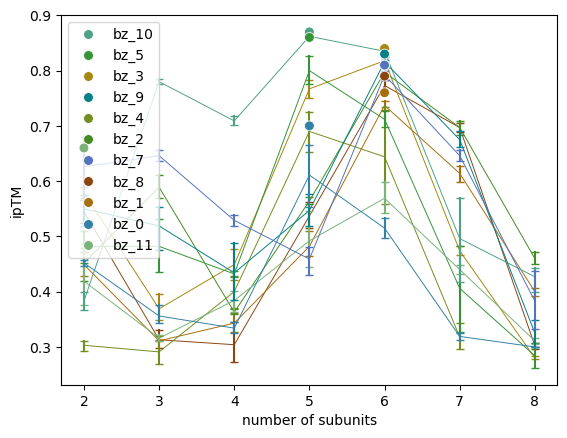

bz_0 ipTM range (5mer with ATP): 0.45 - 0.7
bz_0 ipTM range (6mer with ATP): 0.46 - 0.57

bz_1 ipTM range (5mer with ATP): 0.46 - 0.6
bz_1 ipTM range (6mer with ATP): 0.72 - 0.76

bz_10 ipTM range (5mer with ATP): 0.86 - 0.87
bz_10 ipTM range (6mer with ATP): 0.83 - 0.85

bz_11 ipTM range (5mer with ATP): 0.4 - 0.62
bz_11 ipTM range (6mer with ATP): 0.52 - 0.65

bz_2 ipTM range (5mer with ATP): 0.55 - 0.59
bz_2 ipTM range (6mer with ATP): 0.77 - 0.81

bz_3 ipTM range (5mer with ATP): 0.71 - 0.8
bz_3 ipTM range (6mer with ATP): 0.78 - 0.84

bz_4 ipTM range (5mer with ATP): 0.6 - 0.78
bz_4 ipTM range (6mer with ATP): 0.49 - 0.81

bz_5 ipTM range (5mer with ATP): 0.73 - 0.86
bz_5 ipTM range (6mer with ATP): 0.68 - 0.76

bz_7 ipTM range (5mer with ATP): 0.35 - 0.5
bz_7 ipTM range (6mer with ATP): 0.76 - 0.81

bz_8 ipTM range (5mer with ATP): 0.49 - 0.62
bz_8 ipTM range (6mer with ATP): 0.72 - 0.79

bz_9 ipTM range (5mer with ATP): 0.49 - 0.63
bz_9 ipTM range (6mer with ATP): 0.8 - 0.83



In [26]:
# Structure confidence seems to generally be better with bound Mg + ATP
output_dirs = [path for path in glob.glob(os.path.join('../data/genes/alphafold/af_output', '*')) if re.search(r'bz_\d+_cluster_3_[2-9]mer-mg_atp', path)]

figure_df = list()
for output_dir in output_dirs:
    num_subunits = int(re.search(r'(\d+)mer', output_dir).group(1))
    output = AlphaFoldOutput(output_dir)
    figure_df += [{'genome_id':get_genome_id(output_dir), 'num_subunits':num_subunits, 'iptm':iptm} for iptm in output.get_iptms().values()]
figure_df = pd.DataFrame(figure_df)

fig, ax = plt.subplots()
y = 'iptm'

cmap = LinearSegmentedColormap.from_list('palette',  ['saddlebrown', 'darkgoldenrod', 'olivedrab', 'forestgreen', 'darkseagreen', 'teal', 'steelblue', 'slateblue'])
palette = {genome_id:cmap(i / figure_df.genome_id.nunique()) for i, genome_id in enumerate(figure_df.genome_id.unique())}

sns.lineplot(figure_df, x='num_subunits', y=y, hue='genome_id', lw=0.7, palette=palette, zorder=-1,legend=False, err_style='bars', err_kws={"capsize": 3})

sns.scatterplot(figure_df.sort_values('iptm', ascending=False).drop_duplicates('genome_id'), x='num_subunits', y=y, hue='genome_id', palette=palette, s=50, zorder=10)

ax.set_ylabel('ipTM')
ax.set_xlabel('number of subunits')

ax.legend().set_title('')
sns.move_legend(ax, loc='upper left')

plt.show()

for genome_id, df in figure_df.groupby('genome_id'):
    print(f'{genome_id} ipTM range (5mer with ATP):', df[df.num_subunits == 5].iptm.min(), '-', df[df.num_subunits == 5].iptm.max())
    print(f'{genome_id} ipTM range (6mer with ATP):', df[df.num_subunits == 6].iptm.min(), '-', df[df.num_subunits == 6].iptm.max(), end='\n\n')

# The ipTMs for structures folded without ATP (or ADP) and Mg were substantially worse, so I elected to focus on the ATP-bound structures. 
# This could reflect the fact that ATP binding stabilizes the oligomer somehow, or possibly promotes oligomerization in the first place. 

In [ ]:
# NOTE: Should possibly look into the CONN (Connely) option, but this seems like it might take longer and maybe be unnecessary. 

# Something seems to have gone wrong with the bz_3 HOLE prediction when I did an initial run, as the channel seems to have stopped partway through the pore. 
# I am unsure why, as the pore did not seem especially narrow, although perhaps the issue was that the ENDRAD threshold was met). I decreased the
# SAMPLE parameter from the default (0.25) to 0.1 and increased ENDRAD parameter from 25 to 40. This produced much better results; HOLE captured the complete
# channel, and also was more consistent across runs. I then decided to re-run HOLE on all PDB structures using these parameters. 

# SAMPLE specifies the distance between the planes used in the HOLE procedure. The default value is 0.25 A, this should be reasonable for most purposes; if you wish to visualize a very tight 
# constriction then specify a smaller value. This essentially increases the resolution along the pore. 

HOLE_RAD_PATH = os.path.abspath('../data/genes/hole/rad/simple.rad')
HOLE_INPUT = '''coord {pdb_path}
radius {rad_path}mmetry is clean (e.g., C6 ring for an ATPase).

Conserved motifs
endrad 40
sample 0.1
sphpdb {output_path} 
cpoint {cpoint}
cvect {cvect} 
'''

HOLE_INPUT_DIR = '../data/genes/hole/input'
HOLE_OUTPUT_DIR = '../data/genes/hole/output'


def get_hole_axis(path:str, start_residue_num:int=1, end_residue_num:int=220, atom:str='CA'):
    '''Find the start position (CPOINT) and direction (CVECT) of the pore through a cluster_3 ATPase. 
    This code relies on the multimer being symmetric and a homo-oligomer.
    
    :param path: Path to the PDB file containing the multimer. 
    :param start_residue_num:
    :param end_residue_num:

    '''
    
    pdb_df = PDBFile.from_file(path).to_df()

    coords = dict()
    coords['start'] = np.array(pdb_df[pdb_df.residue_num == start_residue_num][atom].tolist())
    coords['end'] = np.array(pdb_df[pdb_df.residue_num == end_residue_num][atom].tolist())

    # Taking the average over corresponding residues in all chains should be the centroid, or where the pore lies. 
    cpoints = (coords['start'].mean(axis=0), coords['end'].mean(axis=0))
    cvect = cpoints[1] - cpoints[0]
    

    return cpoints[0], cvect


def check_hole_input(input, max_line_length:int=80):
    '''HOLE is old Fortran code, and some versions have fixed-length character buffers (often 80 or 255 characters). Long filenames 
    or paths can cause silent failures.'''
    lines = input.split('\n')
    for line in lines:
        assert len(line) <= max_line_length, f'check_hole_input: Found a line that is {len(line)} characters long.'

def write_hole_input(input_path, **kwargs):
    input = HOLE_INPUT.format(**kwargs)
    check_hole_input(input)
    with open(input_path, 'w') as f:
        f.write(input)


def clean_pdb(pdb_path:str):
    '''HOLE does not support non-amino acid residues in the PDB file (e.g. Mg or ATP), so these need
    to be removed prior to running the program.'''
    with open(pdb_path, 'r') as f:
        lines = f.readlines()
        lines = [line for line in lines if not (line.startswith('HETATM'))] # Remove all non-amino acid entries.
    with open(pdb_path, 'w') as f:
        f.write('\n'.join(lines))
    return pdb_path


model_paths = dict()
pattern = r'bz_\d+_cluster_3_(5|6)mer-mg_(atp|adp)'
keep_dir_path = lambda dir_path : re.match(pattern, os.path.basename(dir_path)) is not None


dir_paths = [dir_path for dir_path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')) if keep_dir_path(dir_path)]
for dir_path in dir_paths: # Iterate over outer directories. 

    name = os.path.basename(dir_path)
    model_paths[name] = dict()

    paths = sorted(glob.glob(os.path.join(dir_path, '*', '*.cif'))) # Make sure these are sorted for consistent ordering. 
    for model, cif_path in enumerate(paths):
        
        pdb_path = os.path.join(HOLE_INPUT_DIR, f'{name}.{model}.pdb') # Path to the source PDB file. 
        input_path = os.path.join(HOLE_INPUT_DIR, f'{name}.{model}.inp') # Path to the HOLE input file. 
        output_path = os.path.join(HOLE_OUTPUT_DIR, f'{name}.{model}.sph') # Path to the HOLE output file. 

        model_paths[name][str(model)] = os.path.abspath(pdb_path) # Store the path to the sub-model under the correct integer model number. 

        if os.path.exists(output_path):
            continue 
        print(f'Running HOLE analysis on structure {name} model {model}')

        pdb_path = clean_pdb(cif_to_pdb(cif_path, output_path=pdb_path))
        cpoint, cvect = get_hole_axis(pdb_path)
        cpoint, cvect = ' '.join([str(n) for n in cpoint]), ' '.join([str(n) for n in cvect])

        write_hole_input(input_path, pdb_path=pdb_path, rad_path=HOLE_RAD_PATH, cvect=cvect, cpoint=cpoint, output_path=output_path)

        subprocess.run(f'hole < {input_path} > /dev/null', shell=True, check=True)
        sph_to_pdb(output_path)


with open('analysis-1-cluster_3_model_paths.json', 'wb') as f:
    orjson.dumps(model_paths, f)

Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 0
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 1
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 2
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 3
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 4
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 5
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 6
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 7
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 8
Running HOLE analysis on structure bz_0_cluster_3_5mer-mg_adp model 9
Running HOLE analysis on structure bz_1_cluster_3_5mer-mg_adp model 0
Running HOLE analysis on structure bz_1_cluster_3_5mer-mg_adp model 1
Running HOLE analysis on structure bz_1_cluster_3_5mer-mg_adp model 2
Running HOLE analysis on structure bz_1_cluster_3_5mer-mg_adp model 3
Running HOLE analysi

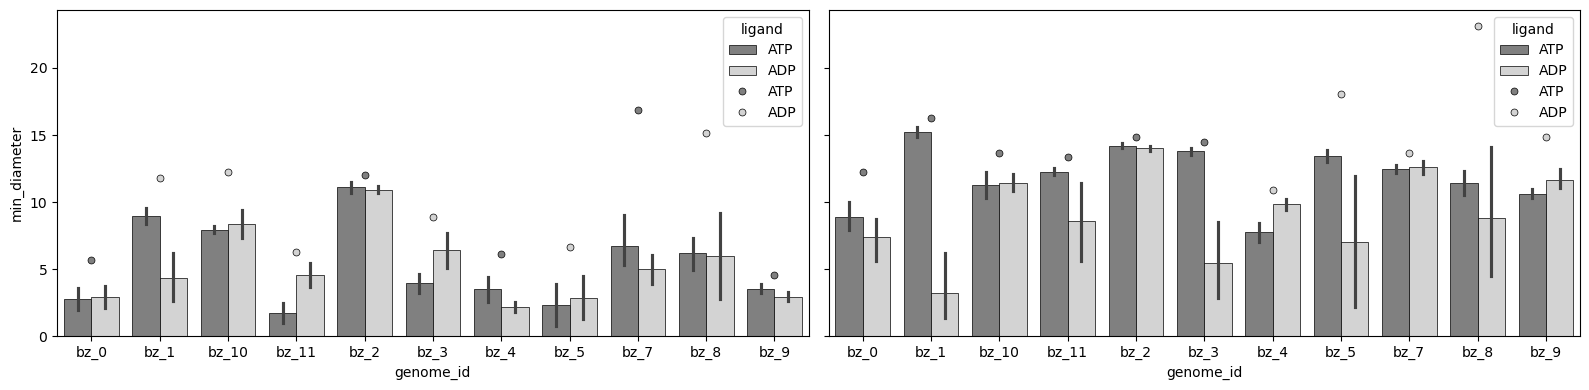

In [ ]:
# First, want to look at the approximate pore diameters (which include the Van Der Waals radius). Based on these results, it seems as though the predictions
# for ATP-bound structures are far more consistent, and generally tend to have larger radii. For subsequent analysis, I will focus on the ATP-bound 6mers. 

fig, axes = plt.subplots(ncols=2, figsize=(16, 4), sharey=True)

# Want num_subunits, ligands, and the constriction point. It would also be useful to get PAE at the constriction point (although
# the actual pore-lining residues will be needed for this)
figure_df = list() 

for path in glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')):
    name, model = os.path.basename(path).replace('.pdb', '').split('.')
    pdb_df = PDBFile.from_file(path).to_df(atoms=['QSS'], residues=['SPH'])

    data = {'name':name, 'model':model, 'genome_id':get_genome_id(name)}
    data['ligand'] = 'ATP' if (('mg_atp') in name) else 'ADP'
    data['num_subunits'] = get_num_subunits(name)
    data['min_radius'] = pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    data['min_diameter'] = 2 * pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    figure_df.append(data)
figure_df = pd.DataFrame(figure_df)

palette = {'ATP':'gray', 'ADP':'lightgray'}

for ax, (num_subunits, df) in zip(axes, figure_df.groupby('num_subunits')):
    df = df.sort_values(['genome_id', 'min_radius'], ascending=[True, False])
    sns.barplot(df, ax=ax, x='genome_id', y='min_diameter', hue='ligand', palette=palette, edgecolor='black', lw=0.5)
    sns.stripplot(df.drop_duplicates('genome_id', keep='first'), ax=ax, x='genome_id', y='min_diameter',  hue='ligand', palette=palette, edgecolor='black', linewidth=0.5)

fig.tight_layout()
plt.show()

In [ ]:
def get_pore_length(sph_center_coords:np.ndarray) -> float:
    '''Compute the approximate pore length from the HOLE output file.
    
    :param sph_center_coords: The coordinates of the spheres from the HOLE output file. This should be a numpy array with shape (n_atoms, 3).
    :returns: The maximum distance between any two spheres centers, which is taken to be the approximate pore length.  
    
    '''
    dists = pdist(sph_center_coords) # pdist returns the upper triangle of the distance matrix (excluding the diagonal), flattened into a 1D array.
    return max(dists)


def get_pore(path:str, sph_center_coords:np.ndarray=None):
    '''Locates the atoms closest to the pore center for each sphere in the HOLE output. This is accomplished by computing the pairwise distance between
    each sphere and all other atoms in the PDB file, and then returning findiing the atom from each chain which is closest to the sphere center. 
    For each sphere, there will be {num_chains} nearest atoms.
    
    :param path: The path to the PDB file containing the AlphaFold structure used to generate the HOLE output. 
    :param sph_center_coords: The coordinates of the spheres from the HOLE output file. This should be a numpy array with shape (n_atoms, 3).
    :returns: 
    '''
    pore_df = list()

    pdb_df = PDBFile.from_file(path, format='pdb').to_df().drop(columns='b_factor')
    pdb_df = pdb_df.melt(value_name='coord', var_name='atom', id_vars=['residue_num', 'residue', 'chain_id'])
    pdb_df = pdb_df.dropna()
    coords = np.array(pdb_df['coord'].tolist())

    for i, coord in enumerate(sph_center_coords):
        coord = np.expand_dims(coord, axis=0)
        dists = cdist(coord, coords).ravel()

        df = pdb_df.copy().assign(distance=dists, sph_idx=i)
        df = df.sort_values('distance', ascending=True).drop_duplicates('chain_id')
        pore_df.append(df)

    return pd.concat(pore_df)


keep_path = lambda path : (get_num_subunits(path) == 6) and ('mg_atp' in path) # Based on pore size and ipTM results, going to focus on 6-mers. 

if not os.path.exists('../data/genes/cluster_3_pores.csv'):
    
    pore_df = list()
    for path in tqdm(glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')), desc='Finding pore-lining residues.'):

        if not keep_path(path):
            continue 

        name, model = os.path.basename(path).replace('.pdb', '').split('.')
        pdb_path = model_paths[name][model] # Path to the PDB file used to generate the HOLE output. 

        hole_df = PDBFile.from_file(path, format='pdb').to_df(atoms=['QSS'], residues=['SPH'])
        hole_df = hole_df.sort_values('residue_num') # Residue number is the position along the pore. 
        
        # This should be in order of position through the channel (which is the pseudo-"residue number" in the PDB file). 
        sph_center_coords = np.array(hole_df['QSS'].tolist()) # Should be a numpy array with shape (n_atoms, 3). 

        df = get_pore(pdb_path, sph_center_coords=sph_center_coords)
        df['name'], df['model'], df['genome_id'] = name, model, get_genome_id(name)
        df['pore_length'] = get_pore_length(sph_center_coords)
        pore_df += [df]

    pore_df = pd.concat(pore_df)
    pore_df.to_csv('../data/genes/cluster_3_pores.csv', index=False)

pore_df = pd.read_csv('../data/genes/cluster_3_pores.csv')

plot_pore: Minimum diameter of 14.536423851388824 at SPH 776.


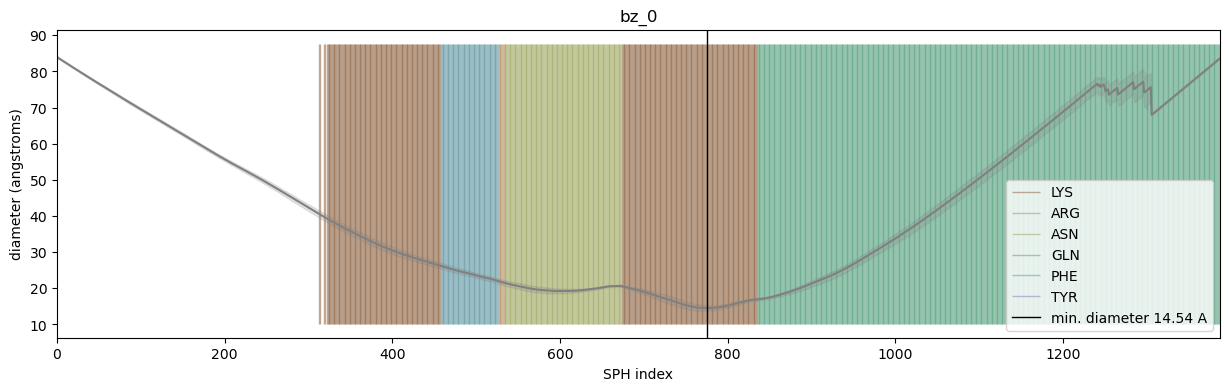

plot_pore: Minimum diameter of 19.23556182654062 at SPH 781.


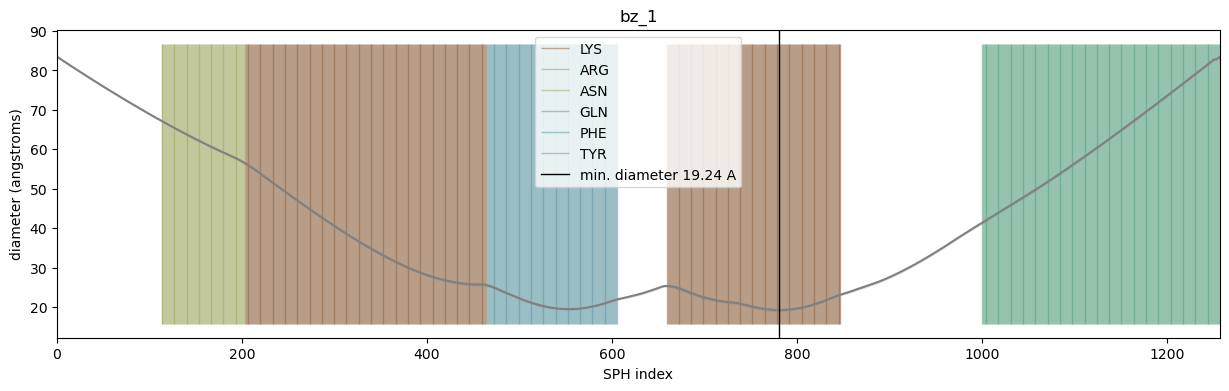

plot_pore: Minimum diameter of 15.02921480237656 at SPH 792.


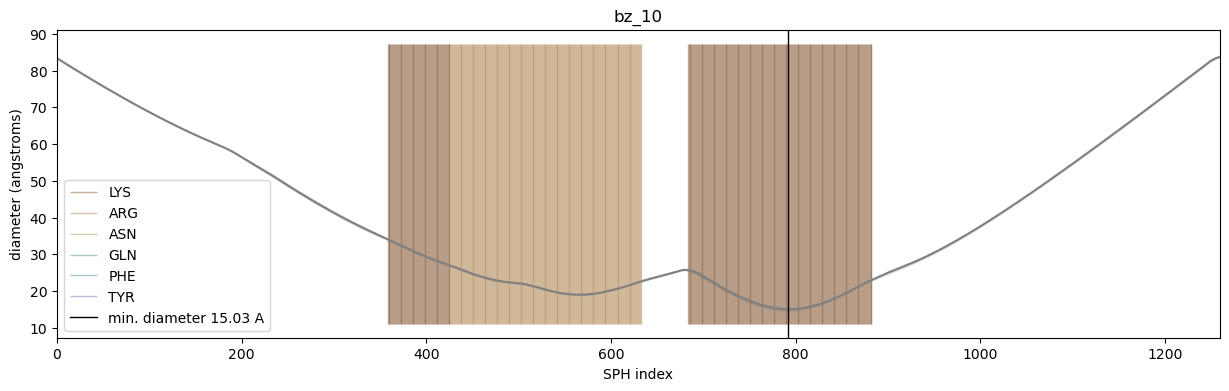

plot_pore: Minimum diameter of 16.089612513431653 at SPH 714.


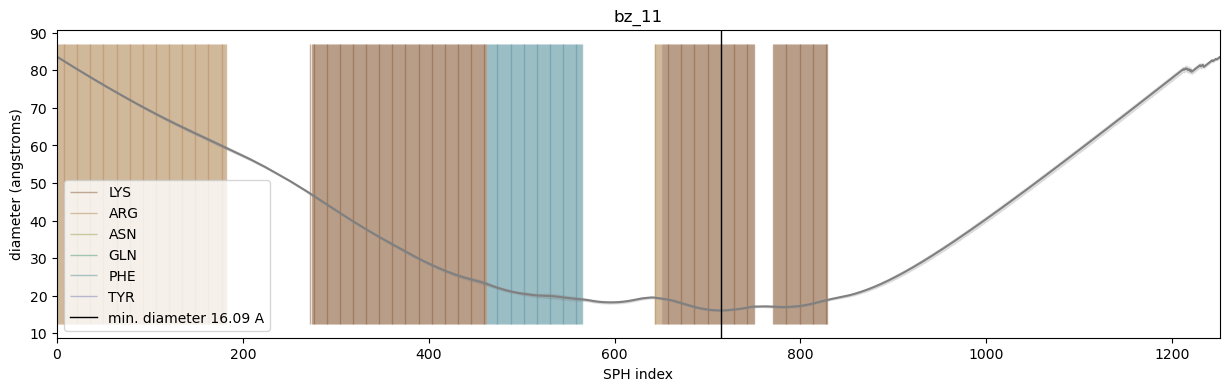

plot_pore: Minimum diameter of 17.676913288008237 at SPH 789.


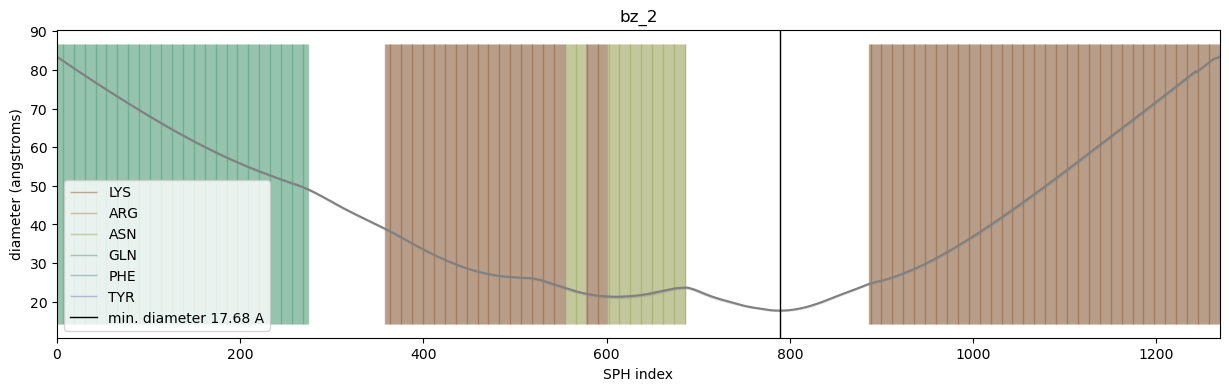

plot_pore: Minimum diameter of 17.847668350772896 at SPH 840.


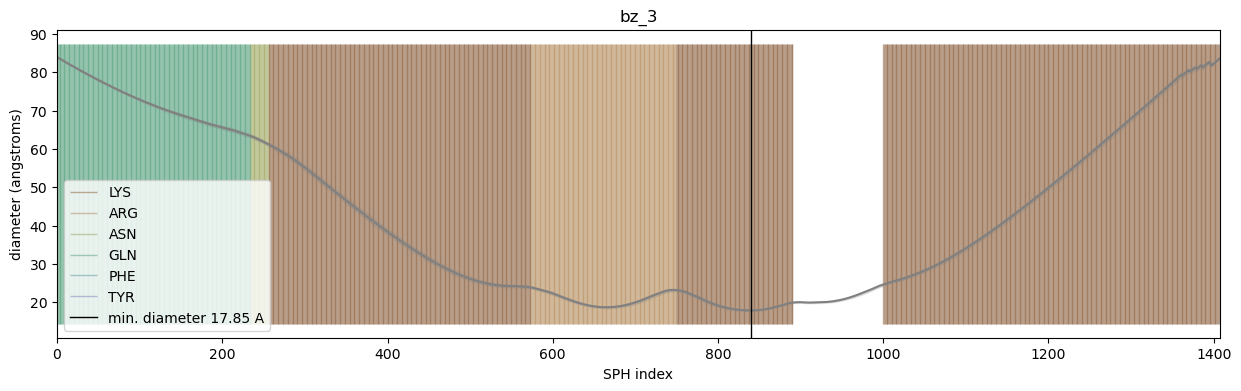

plot_pore: Minimum diameter of 11.819954802762128 at SPH 769.


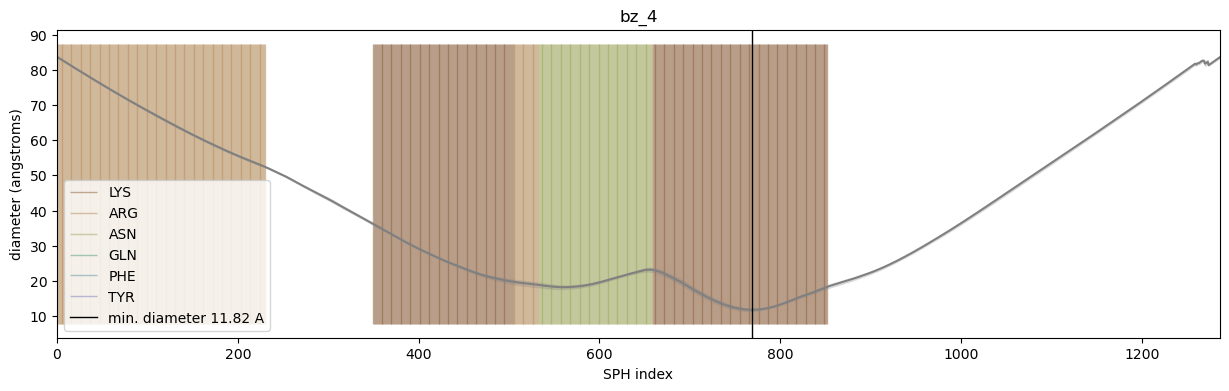

plot_pore: Minimum diameter of 17.67888279040466 at SPH 836.


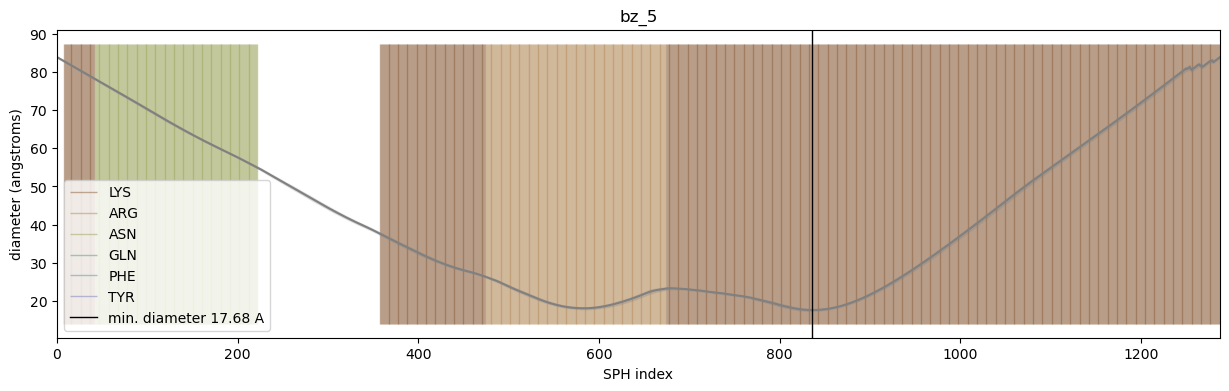

plot_pore: Minimum diameter of 16.699437114884137 at SPH 637.


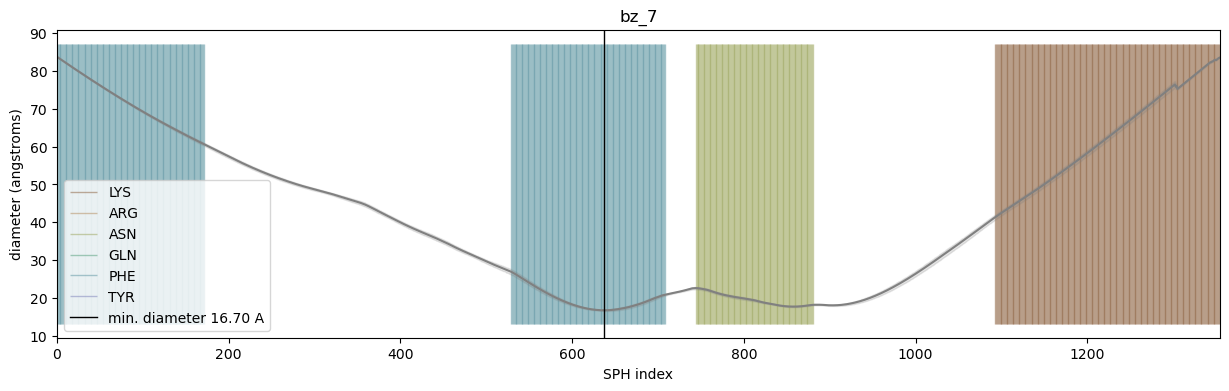

plot_pore: Minimum diameter of 15.156838526908176 at SPH 745.


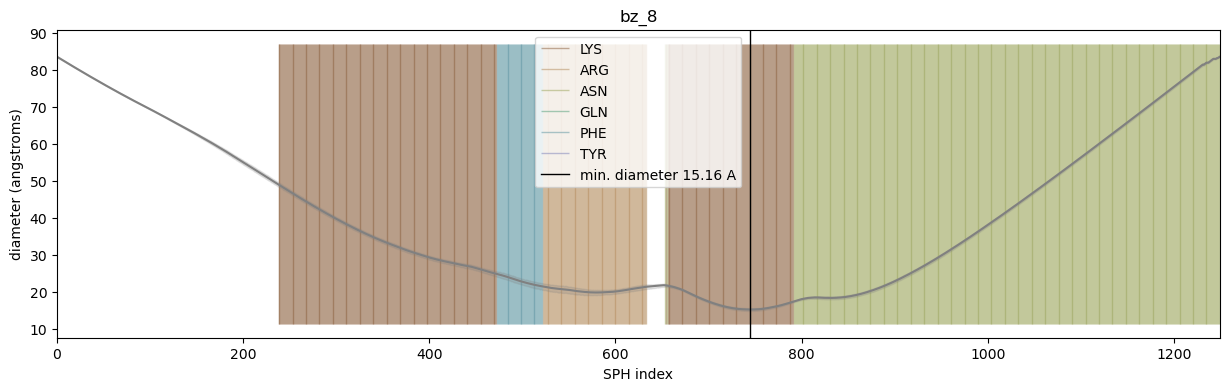

plot_pore: Minimum diameter of 14.54557756099223 at SPH 639.


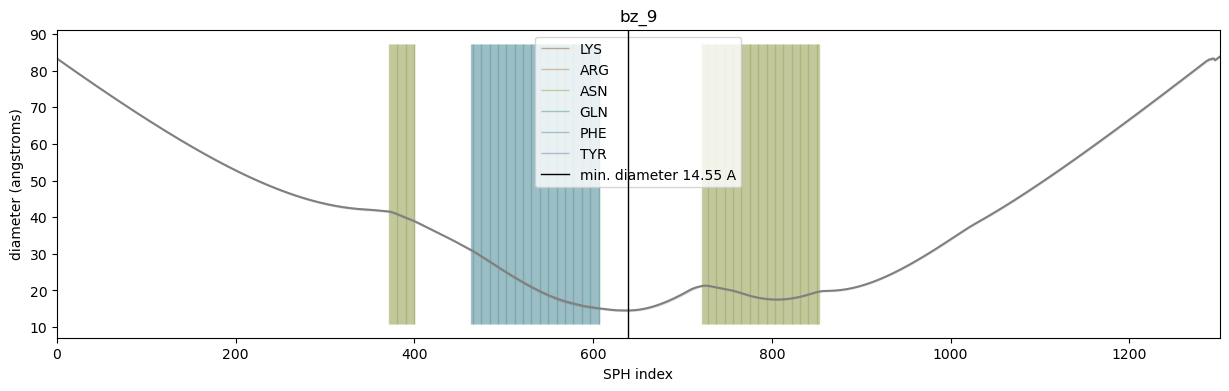

In [ ]:
residues = ['LYS', 'ARG', 'ASN',  'GLN', 'PHE', 'TYR']
colors = ['#8A5E3B', '#B38A5A', '#9AA45A', '#4F9D78', '#5A93A0', '#7A7FB8']
palette = dict(zip(residues, colors))

def plot_pore(pore_df:pd.DataFrame, palette=palette, path:str=None, title:str=None):

    figure_df = pore_df.copy()
    figure_df['diameter'] = figure_df.distance * 2 # This will not include the Van Der Waals radius. 
    figure_df['ligand'] = figure_df['name'].apply(lambda name : 'ATP' if (('mg_atp') in name) else 'ADP')

    # Want to obtain the closest residue from each chain for each sphere center, so there should be num_subunits entries per sph_idx.

    fig, ax = plt.subplots(figsize=(15, 4))

    # I checked, and none of the spheres share the same residue across all models, which could be due to small variations in the 
    # models, or because there are different numbers of spheres... or who knows. 

    df = list()
    for idx, df_ in figure_df.groupby('sph_idx'):
        row = {'sph_idx':idx}
        row['consensus_residue'] = df_.residue.value_counts().index[0]
        row['consensus_residue_confidence'] = (df_.residue == row['consensus_residue']).mean()
        df.append(row)
    figure_df = figure_df.merge(pd.DataFrame(df), how='left', on='sph_idx')

    sns.lineplot(figure_df, x='sph_idx', y='diameter', color='gray')
    y_min, y_max = ax.get_ylim()

    for residue, color in palette.items():
        idxs = figure_df[figure_df.consensus_residue == residue].sph_idx.unique()
        ax.vlines(idxs, ymin=y_min, ymax=y_max, color=color, zorder=-1, alpha=0.5, label=residue, lw=1)

    diameters = figure_df.groupby('sph_idx').diameter.mean()
    min_diameter_idx = np.argmin(diameters)
    min_diameter = min(diameters) 
    print(f'plot_pore: Minimum diameter of {min_diameter} at SPH {min_diameter_idx}.')
    ax.axvline(min_diameter_idx, color='black', label=f'min. diameter {min_diameter:.2f} A', zorder=1000, lw=1)

    ax.legend()

    ax.set_xlim(xmin=0, xmax=figure_df.sph_idx.max())
    ax.set_xlabel('SPH index')
    ax.set_ylabel('diameter (angstroms)')

    if title is not None:
        ax.set_title(title)

    if path is not None:
        fig.savefig(path, dpi=500, format='png')
    plt.show()

for genome_id, df in pore_df.groupby('genome_id'):
    plot_pore(df, path=os.path.join(FIGURE_DIR, f'pore_{genome_id}_atp.png'), title=genome_id)

# I took a look at the PAEs, which were around 10-15 A around the constriction points. However, because model predictions are consistently 
# predicting fairly small pores, I think it is likely that the substrate is ssDNA.

In [ ]:
# In general it seems as though the ATP-bound structures are higher-confidence than the ADP-bound structures. 



for genome_id, residues_ in residues.items():
    output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, f'{genome_id}_cluster_3_6mer-mg_atp'))
    x = get_inter_chain_pae(output, residues=residues_, expected_num_chains=6)
    break


check_token_chain_ids: Condition (1) OK
check_token_chain_ids: Condition (2) OK


In [53]:
genome_id

'bz_0'

In [56]:
x.sort_values('min_pae')

,model,name,residue,distance,residue_num,paes,mean_pae,min_pae
137,seed-2_sample-0,bz_0_cluster_3_6mer-mg_atp,HIS,27.334184,189,"[11.9, 12.0, 12.0, 12.4, 12.5, 12.6, 18.5, 18....",16.900000,11.9
139,seed-2_sample-2,bz_0_cluster_3_6mer-mg_atp,HIS,27.334184,189,"[12.4, 12.6, 12.6, 12.6, 12.7, 12.7, 19.1, 19....",17.280000,12.4
7,seed-2_sample-0,bz_0_cluster_3_6mer-mg_atp,LYS,5.116183,224,"[12.5, 12.6, 12.9, 13.0, 13.0, 13.2, 17.9, 18....",16.673333,12.5
9,seed-2_sample-2,bz_0_cluster_3_6mer-mg_atp,LYS,5.116183,224,"[12.7, 13.0, 13.0, 13.1, 13.2, 13.6, 17.9, 18....",16.593333,12.7
39,seed-2_sample-2,bz_0_cluster_3_6mer-mg_atp,GLN,8.055070,226,"[12.7, 13.1, 13.3, 13.5, 13.6, 15.1, 18.9, 19....",17.326667,12.7
...,...,...,...,...,...,...,...,...
70,seed-2_sample-1,bz_0_cluster_3_6mer-mg_atp,ARG,10.857183,2,"[30.1, 30.2, 30.2, 30.2, 30.2, 30.2, 30.3, 30....",30.293333,30.1
78,seed-1_sample-0,bz_0_cluster_3_6mer-mg_atp,ARG,10.857183,2,"[30.2, 30.2, 30.2, 30.2, 30.2, 30.4, 30.5, 30....",30.446667,30.2
73,seed-1_sample-4,bz_0_cluster_3_6mer-mg_atp,ARG,10.857183,2,"[30.2, 30.2, 30.2, 30.3, 30.3, 30.3, 30.4, 30....",30.406667,30.2
72,seed-1_sample-1,bz_0_cluster_3_6mer-mg_atp,ARG,10.857183,2,"[30.3, 30.3, 30.3, 30.4, 30.4, 30.4, 30.5, 30....",30.506667,30.3


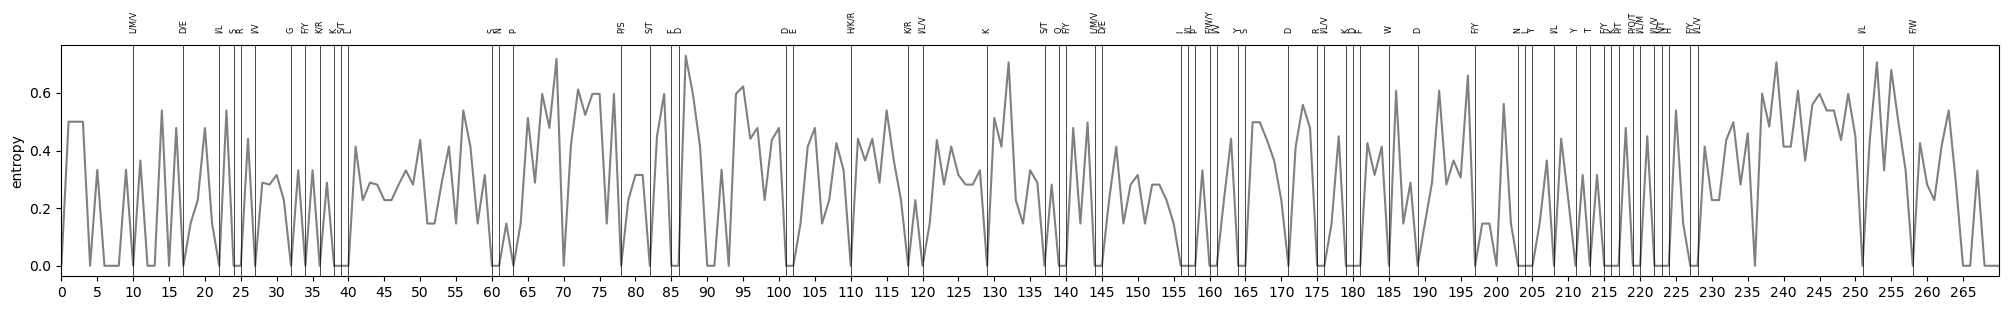

In [ ]:
MAX_ENTROPY = 0.1
msa = MSA.from_file(path='../data/genes/cluster_3.afa')

def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

# x_min, x_max = 240, 270
x_min, x_max = 0, 270
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
ax.plot(np.arange(len(entropy)), entropy, color='gray')

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

ax.set_xticks(np.arange(x_min, x_max, 5))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

In [ ]:
ref_gene_id = 'orfm.bz_10.1_15' # One of the higher-confidence structures. 
print(f'{ref_gene_id} PHE 92:', msa.map_idx_to_msa(92 - 1, ref_gene_id))
print(f'{ref_gene_id} PHE 125:', msa.map_idx_to_msa(125 - 1, ref_gene_id)) # Highly conserved, either F or Y. 
print(f'{ref_gene_id} PHE 124:', msa.map_idx_to_msa(124 - 1, ref_gene_id)) # Highly conserved, either F or Y. 
print(f'{ref_gene_id} PHE 221:', msa.map_idx_to_msa(221 - 1, ref_gene_id)) 
print(f'{ref_gene_id} PHE 203:', msa.map_idx_to_msa(203 - 1, ref_gene_id)) 
print(f'{ref_gene_id} PHE 209:', msa.map_idx_to_msa(209 - 1, ref_gene_id)) 
print(f'{ref_gene_id} LYS 214:', msa.map_idx_to_msa(214 - 1, ref_gene_id)) 

msa.show(start=100, stop=110)
msa.map_idx_from_msa(85, ref_gene_id) # Buried. 
msa.map_idx_from_msa(205, ref_gene_id) # On the outside of complex.
msa.map_idx_from_msa(211, ref_gene_id) # Buried.
msa.map_idx_from_msa(215, ref_gene_id) # Buried.
msa.map_idx_from_msa(34, ref_gene_id) # Buried.
msa.map_idx_from_msa(175, ref_gene_id) # Buried.
msa.map_idx_from_msa(118, ref_gene_id) # Possible contact.
msa.map_idx_from_msa(179, ref_gene_id) # Outside of pore.
msa.map_idx_from_msa(140, ref_gene_id) # Outside of pore.

orfm.bz_10.1_15 PHE 92: 108
orfm.bz_10.1_15 PHE 125: 141
orfm.bz_10.1_15 PHE 124: 140
orfm.bz_10.1_15 PHE 221: 243
orfm.bz_10.1_15 PHE 203: 221
orfm.bz_10.1_15 PHE 209: 227
orfm.bz_10.1_15 LYS 214: 232
100	MDELHNDVNA	110	orfm.bz_2.1_22
100	LDELQSILNS	110	orfm.bz_8.1_215
100	MDEMQNDLDS	110	orfm.bz_1.1_155
100	HDELQRDFGS	110	orfm.bz_7.1_194
100	HDELQRDFNS	110	orfm.bz_9.1_34
100	WDEIYADLFS	110	orfm.bz_10.1_15
100	YDEIHLDLNA	110	orfm.bz_5.1_151
100	YDEIHMDLNA	110	orfm.bz_3.1_43
100	WDEMPNDINA	110	orfm.bz_0.1_191
100	WDETTNDINA	110	orfm.bz_4.1_184
100	WDEMTNDLPA	110	orfm.bz_11.1_23


123

In [ ]:
# The lysine/arginine (K/R) at positions 118 and 129 are particularly interesting. 
kr118_idx = 118
k129_idx = 129
k216_idx = 216
phe85 = 85

for row in genes_df.itertuples():
    info = f'{row.genome_id}: '
    info += 'K/R118: ' + str(msa.map_idx_from_msa(kr118_idx, row.Index) + 1)
    info += '\tK129: ' + str(msa.map_idx_from_msa(k129_idx, row.Index) + 1)
    info += '\tK216: ' + str(msa.map_idx_from_msa(k216_idx, row.Index) + 1)
    print(info)

# In bz_1, K222 looks important. Also Phe96. 
# msa.map_idx_to_msa(221, 'orfm.bz_1.1_155')
# msa.map_idx_to_msa(95, 'orfm.bz_1.1_155')

bz_0: K/R118: 111	K129: 122	K216: 208
bz_1: K/R118: 102	K129: 113	K216: 199
bz_2: K/R118: 102	K129: 113	K216: 198
bz_3: K/R118: 108	K129: 119	K216: 204
bz_4: K/R118: 101	K129: 112	K216: 198
bz_5: K/R118: 103	K129: 114	K216: 199
bz_7: K/R118: 107	K129: 118	K216: 203
bz_8: K/R118: 103	K129: 114	K216: 199
bz_9: K/R118: 97	K129: 108	K216: 193
bz_10: K/R118: 102	K129: 113	K216: 198
bz_11: K/R118: 101	K129: 112	K216: 198


In [ ]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'accession', 'description', 'start','stop', 'e_value', 'status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
INTERPROSCAN_ATPASE_ACCESSIONS = ['G3DSA:3.40.50.300', 'SSF52540']

def load_atpase_annotations(path:str, gene_ids:list=None):
    df = pd.read_csv(path, sep='\t', header=None, names=INTERPROSCAN_FIELDS)
    if gene_ids is not None:
        df = df[df.gene_id.isin(gene_ids)].copy()
    df = df[df.accession.isin(INTERPROSCAN_ATPASE_ACCESSIONS)].copy() # P-loop containing nucleoside triphosphate hydrolase
    df = df.sort_values('e_value').drop_duplicates('gene_id')
    df['gene_id'] = df.gene_id.str.lower()
    print(f'load_atpase_annotations: Found {df.gene_id.nunique()} genes with ATPase annotations in {path}.')
    return df.drop(columns=['status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways', 'checksum'])

print('P-loop containing nucleoside triphosphate hydrolase domain indices:')
for row in load_atpase_annotations('../data/genes/interproscan/genes.tsv', gene_ids=genes_df.index.values).itertuples():
    start, stop = msa.map_idx_to_msa(row.start, row.gene_id), msa.map_idx_to_msa(row.stop, row.gene_id)
    print(f'{row.gene_id}\t{start}-{stop}')


P-loop containing nucleoside triphosphate hydrolase domain indices:
load_atpase_annotations: Found 5 genes with ATPase annotations in ../data/genes/interproscan/genes.tsv.
orfm.bz_10.1_15	25-190
orfm.bz_8.1_215	25-158
orfm.bz_9.1_34	24-214
orfm.bz_7.1_194	24-199
orfm.bz_1.1_155	24-200


In [ ]:
WALKER_A_PATTERN = r'[A-Z][A-Z]{4}GK[ST]' # More general version, instead of r'[GAST][A-Z]{4}GK[ST]' 
WALKER_B_PATTERN = r'[AVLIMFYWC]{3,5}D[ED]' # More general version, instead of r'[AVLIMFYWC]{4}D[ED]' 


for row in msa.to_df().itertuples():
    wa_match = re.search(WALKER_A_PATTERN, row.seq)
    wb_match = re.search(WALKER_B_PATTERN, row.seq)

    info = f'{row.Index}'
    if wa_match is not None:
        info += f' Walker-A: {wa_match.group(0)} ({wa_match.start()} - {wa_match.end()})'
    if wb_match is not None:
        info += f' Walker-B: {wb_match.group(0)} ({wb_match.start()} - {wb_match.end()})'
    print(info)

WALKER_A_COORDS = (32, 40)
WALKER_B_COORDS = (96, 103)

for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'walker_a_start'] = msa.map_idx_from_msa(WALKER_A_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_a_stop'] = msa.map_idx_from_msa(WALKER_A_COORDS[1], gene_id)
    genes_df.loc[gene_id, 'walker_b_start'] = msa.map_idx_from_msa(WALKER_B_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_b_stop'] = msa.map_idx_from_msa(WALKER_B_COORDS[1], gene_id)
# Based on the sructure, residues ~100-140 are pointed towards the inside of the toroid. 
# Residues 220-250 also look like they would be in contact with whatever is moving through the toroid. 
# ATPs look like they are binding by the W-A motif, which is good. 

print()
msa.show(start=32, stop=40)

orfm.bz_2.1_22 Walker-B: CIYIMDE (96 - 103)
orfm.bz_8.1_215 Walker-B: IIILDE (97 - 103)
orfm.bz_1.1_155 Walker-A: GEFGRGKT (32 - 40) Walker-B: LFIMDE (97 - 103)
orfm.bz_7.1_194 Walker-A: GEYGRGKS (32 - 40)
orfm.bz_9.1_34 Walker-A: GEYGRGKT (32 - 40)
orfm.bz_10.1_15 Walker-A: GRFGKGKS (32 - 40) Walker-B: LIIWDE (97 - 103)
orfm.bz_5.1_151 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_3.1_43 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_0.1_191 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_4.1_184 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_11.1_23 Walker-A: GRYSRGKS (32 - 40) Walker-B: IVWDE (98 - 103)

32	GEYGRSKS	40	orfm.bz_2.1_22
32	GEFGRCKS	40	orfm.bz_8.1_215
32	GEFGRGKT	40	orfm.bz_1.1_155
32	GEYGRGKS	40	orfm.bz_7.1_194
32	GEYGRGKT	40	orfm.bz_9.1_34
32	GRFGKGKS	40	orfm.bz_10.1_15
32	GRYSRGKS	40	orfm.bz_5.1_151
32	GRYSRGKS	40	orfm.bz_3.1_43
32	GRYSRGKS	40	orfm.bz_0.1_191
32	GRYSRGKS	40	orfm.bz_4.1_184
32	GRYSRGKS	40	orfm.bz_11.1_23


In [ ]:
chimerx_commands = ['color gray']
chimerx_commands += ['sel :lys; color sel blue']
chimerx_commands += ['sel :arg; color sel red']
chimerx_commands += ['sel :tyr; color sel green']
chimerx_commands += ['sel :trp; color sel yellow']
chimerx_commands += ['sel :phe; color sel orange']

print('; '.join(chimerx_commands))

idxs = [139]
chains = 'FC'
atom = 'NZ'
chimerx_commands = list()
for idx in idxs:
    chimerx_commands += [f'select /{chains[0]}:{idx}@{atom} /{chains[1]}:{idx}@{atom}; distance sel']
chimerx_commands += ['color white pseudobonds; color white label']
print('; '.join(chimerx_commands))
# select /B:224@NZ /E:224@NZ
# distance sel 

# color white pseudobonds 
# color white label

# Oddly, the residues which are conserved do not appear to be the ones lining the channel (based on examination of the structures). 
# It seems possible that the structures are off, or possibly adopt different conformations. Might be worth folding with dsDNA and ssDNA and then look at 
# which residues are closest to the nucleic acid through the pore. 

# Some of the pentameric configurations (e.g. bz_3 bound to Mg and ATP) have a pore size that seems too small to be biologically-relevant
# (like 6 angstroms). This would be on the small side, even if the substrate were ssDNA. 

color gray; sel :lys; color sel blue; sel :arg; color sel red; sel :tyr; color sel green; sel :trp; color sel yellow; sel :phe; color sel orange
select /F:139@NZ /C:139@NZ; distance sel; color white pseudobonds; color white label


In [ ]:
# This DataFrame contains the numbers of the pore residues, obtained by manual inspection of the AlphaFold structures. 
chimerx_df = pd.read_csv('../data/genes/cluster_3_chimerx.csv')
chimerx_df['complex_id'] = chimerx_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)
pore_residue_nums = chimerx_df.groupby('complex_id').residue_num.apply(list).to_dict()
# file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'



ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
ATOMS = ['NZ', 'CA', 'CB', 'CZ']

pdb_df = list()
for (genome_id, gene_id, num_subunits), df in chimerx_df.groupby(['genome_id', 'gene_id', 'num_subunits']):
    path = os.path.join(ALPHAFOLD_OUTPUT_DIR, f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp', f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp_model.cif')
    pdb_file = PDBFile.from_file(path)
    pdb_df.append(pdb_file.to_df().assign(genome_id=genome_id, gene_id=gene_id, num_subunits=num_subunits))
    
pdb_df = pd.concat(pdb_df)
pdb_df['complex_id'] = pdb_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)

In [ ]:
pore_residue_nums['bz_1_cluster_3_6mer']

[222, 96, 130, 125, 94]

In [ ]:
# Convert AlphaFold structures to PDB for pore analysis using MOLE. 

file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*', '*')):
    if re.search(file_name_pattern, path) is None:
        continue

    pdb_file = PDBFile.from_file(path)
    output_file_name = os.path.basename(path).replace('.cif', '.pdb')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if not os.path.exists(output_path):
        pdb_file.write(output_path)


In [ ]:
FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/cluster_3'
FOLDSEEK_TMP_DIR = '../data/tmp'
FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/cluster_3/cluster_3'
FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/cluster_3.out/cluster_3.out'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/cluster_3.tsv'

COLABFOLD_DIR = '../data/genes/colabfold'
COLABFOLD_FILE_NAME_PATTERN = '*_relaxed_rank_001_alphafold2_ptm_model*'

print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# foldseek_align_df = foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')

foldseek createdb ../data/genes/foldseek/structures/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3
foldseek search ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3.out/cluster_3.out ../data/tmp --alignment-type 1 -a
foldseek convertalis ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3.out/cluster_3.out ../data/genes/foldseek/cluster_3.tsv --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"


In [ ]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df['num_gaps'] = [max(row.qaln.count('-'), row.taln.count('-')) for row in foldseek_search_df.itertuples()]
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

Number of Foldseek hits for orfm.bz_0.1_191: 3994 	alphafold_uniprot (1218) alphafold_swissprot (949) pdb (921) bfvd (906)
Number of Foldseek hits for orfm.bz_1.1_155: 4030 	alphafold_uniprot (1217) alphafold_swissprot (975) pdb (956) bfvd (882)
Number of Foldseek hits for orfm.bz_10.1_15: 4038 	alphafold_uniprot (1218) alphafold_swissprot (954) pdb (951) bfvd (915)
Number of Foldseek hits for orfm.bz_11.1_23: 4052 	alphafold_uniprot (1217) alphafold_swissprot (982) pdb (933) bfvd (920)
Number of Foldseek hits for orfm.bz_2.1_22: 4059 	alphafold_uniprot (1215) alphafold_swissprot (992) pdb (953) bfvd (899)
Number of Foldseek hits for orfm.bz_3.1_43: 4078 	alphafold_uniprot (1215) alphafold_swissprot (987) pdb (956) bfvd (920)
Number of Foldseek hits for orfm.bz_4.1_184: 3948 	alphafold_uniprot (1215) alphafold_swissprot (959) pdb (908) bfvd (866)
Number of Foldseek hits for orfm.bz_5.1_151: 4057 	alphafold_uniprot (1217) alphafold_swissprot (990) pdb (953) bfvd (897)
Number of Foldseek

In [ ]:
filters = dict()
# filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['too_many_gaps'] = (foldseek_search_df.gapopen > 15) | (foldseek_search_df.num_gaps > 50)
# filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.6
# filters['short_target'] = (foldseek_search_df.tlen < 50) | (foldseek_search_df.num_gaps > 50)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')

apply_filters: 40321 entries removed by too_many_gaps.


In [ ]:
foldseek_search_categories = dict()
foldseek_search_categories['RecA'] = foldseek_search_df.theader.str.contains('RecA|recA')
foldseek_search_categories['Zot'] = foldseek_search_df.theader.str.contains('Zot|Zona|occludens')
foldseek_search_categories['ATPase'] = foldseek_search_df.theader.str.contains('ATP|AAA')
foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('uncharacterized', case=False) 
foldseek_search_categories['PhoH'] = foldseek_search_df.theader.str.contains('PhoH') 
foldseek_search_categories['terminase'] = foldseek_search_df.theader.str.contains('terminase') 
foldseek_search_categories['helicase'] = foldseek_search_df.theader.str.contains('helicase', case=False) 
foldseek_search_categories['recombinase'] = foldseek_search_df.theader.str.contains('recombinase', case=False) 
foldseek_search_categories['transposase'] = foldseek_search_df.theader.str.contains('transposase', case=False) 
foldseek_search_categories['RFC'] = foldseek_search_df.theader.str.contains('Replication factor C|Clamp Loader|RFC') 
foldseek_search_categories['MutS'] = foldseek_search_df.theader.str.contains('MutS|mismatch repair', case=False) 
foldseek_search_categories['thymidine kinase'] = foldseek_search_df.theader.str.contains('thymidine kinase', case=False) 
foldseek_search_categories['pilus assembly'] = foldseek_search_df.theader.str.contains('pilus', case=False) # No hits survive the filter. 
# items() output is [(key, value), (key, value), ...]. Then zip() takes the corresponding elements of each tuple, so end up with [(key, key, ...), (value, value, ..)]
foldseek_search_categories = list(zip(*list(foldseek_search_categories.items())))
foldseek_search_df['category'] = np.select(condlist=foldseek_search_categories[-1], choicelist=foldseek_search_categories[0], default='none')


In [ ]:
# RecA forms a filament, not a pore, so a RecA-like mechanism is unlikely. 

foldseek_search_df[foldseek_search_df.category == 'helicase'][['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore')
foldseek_search_df[['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore').iloc[-10:]

,theader,tcov,qcov,alntmscore
153292,AF-X1CVG9-F1-model_v6 Zona occludens toxin N-t...,0.956,0.553,0.9047
195954,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.875,0.9048
117506,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.839,0.9062
135183,A0A6J5KM92,0.362,0.146,0.9067
55250,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.849,0.9069
56466,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.966,0.815,0.9082
77579,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.801,0.9142
151,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.854,0.9181
135155,A0A8S5VDT6,0.376,0.146,0.9209
153182,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.848,0.9217


In [ ]:
genes_df

,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,seq_untrimmed,nt_seq_untrimmed,num_residues_trimmed,cluster_id,atpase_domain_start,atpase_domain_stop,walker_a_start,walker_a_stop,walker_b_start,walker_b_stop
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_191,TTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAAAGGAAA...,NaN,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2,191,1800,2588,-,False,True,...,KSLRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLT...,AAATCTTTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAA...,2,3.0,21.0,206.0,29.0,37.0,88.0,95.0
orfm.bz_1.1_155,ATGACTTCAATATCTGAAATATTTGATATTATTTTTTCAAGGAAAA...,NaN,MTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILNNKNN...,1,155,2418,3179,-,False,True,...,KIKIMTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILN...,AAAATAAAAATTATGACTTCAATATCTGAAATATTTGATATTATTT...,4,3.0,12.0,197.0,20.0,28.0,79.0,86.0
orfm.bz_2.1_22,ATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTCGCCACATTA...,NaN,MNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNKKLI...,6,22,1172,1982,-,False,True,...,NINMNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNK...,AATATAAATATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTC...,3,3.0,11.0,196.0,19.0,27.0,79.0,86.0
orfm.bz_3.1_43,ATGCAAACAAATAGGAAAATAATGAATAATAAAGAAATAATTGAAT...,NaN,MQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSLTALNFFDMI...,5,43,2530,3331,-,False,True,...,YIPKINKFSMQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSL...,TACATACCAAAAATTAATAAATTTTCAATGCAAACAAATAGGAAAA...,9,3.0,18.0,202.0,26.0,34.0,85.0,92.0
orfm.bz_4.1_184,TTGAAAGAAATTGATATAATACAATTGATATTAAGTAGATATGTGG...,NaN,LKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNNRNSI...,1,184,4053,4817,-,False,True,...,IGCILKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNN...,ATAGGGTGTATCTTGAAAGAAATTGATATAATACAATTGATATTAA...,4,3.0,11.0,196.0,19.0,27.0,78.0,85.0
orfm.bz_5.1_151,GTGAAAAAAATGATATTATCCAATATAGAAATATTAAAACTTATAC...,NaN,VKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIMLN...,1,151,1325,2095,-,False,True,...,GKVKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIM...,GGAAAGGTGAAAAAAATGATATTATCCAATATAGAAATATTAAAAC...,2,3.0,16.0,197.0,24.0,32.0,80.0,87.0
orfm.bz_7.1_194,TTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTATTT...,NaN,LFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVLS...,1,194,1204,1989,-,False,True,...,WLFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVL...,TGGTTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTA...,1,3.0,16.0,201.0,24.0,32.0,84.0,91.0
orfm.bz_8.1_215,ATGAATAATTTAGATAAACTTAATATTATTTTCAGTAGATGGATAA...,NaN,MNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTKKSKI...,3,215,1806,2576,-,False,True,...,IKIIMNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTK...,ATCAAGATAATTATGAATAATTTAGATAAACTTAATATTATTTTCA...,4,3.0,11.0,197.0,19.0,27.0,80.0,87.0
orfm.bz_9.1_34,ATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAAAGGTAA...,NaN,MNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHFNV...,4,34,2676,3426,-,False,True,...,KIMNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHF...,AAAATCATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAA...,2,3.0,11.0,191.0,19.0,27.0,74.0,81.0


In [ ]:
# Is there a conserved in-frame start codon?
for row in genes_df.itertuples():
    codons = np.array([row.nt_seq[i:i+3] for i in range(0, len(row.nt_seq), 3)])
    start_codon_idxs = np.where(np.isin(codons, ['ATG', 'GTG']))[0]
    print(f'{row.Index} start codon locations:', ' '.join(start_codon_idxs.astype(str)), '-', len(row.seq))

orfm.bz_0.1_191 start codon locations: 10 45 47 53 59 72 84 95 229 249 255 256 - 259
orfm.bz_1.1_155 start codon locations: 0 30 83 86 96 104 137 157 192 213 - 248
orfm.bz_2.1_22 start codon locations: 0 49 83 96 134 191 199 222 242 - 266
orfm.bz_3.1_43 start codon locations: 0 7 44 52 56 94 197 - 257
orfm.bz_4.1_184 start codon locations: 14 35 49 126 165 191 245 246 - 249
orfm.bz_5.1_151 start codon locations: 0 3 43 54 167 192 202 - 253
orfm.bz_7.1_194 start codon locations: 2 5 40 129 171 253 - 259
orfm.bz_8.1_215 start codon locations: 0 49 55 132 135 138 192 - 251
orfm.bz_9.1_34 start codon locations: 0 51 103 119 176 186 228 - 247
orfm.bz_10.1_15 start codon locations: 0 18 31 51 126 131 155 191 230 239 - 244
orfm.bz_11.1_23 start codon locations: 0 3 35 49 61 85 130 188 246 - 249


In [ ]:
# def check_token_chain_ids(token_chain_ids, paes):
#     '''Checks the following conditions:
#         (1) The retrieved token_chain_ids match the index and columns of each PAE DataFrame. 
#         (2) All chains are of equal length. This should be true for all cluster_3 multimer protein chains, as they are all homo-oligomers.'''
#     for _, df in paes.items():
#         assert np.all(token_chain_ids == df.columns.values), f'check_token_chain_ids: Failed condition (1).'
#         assert np.all(token_chain_ids == df.index.values), f'check_token_chain_ids: Failed condition (1).'
#     print('check_token_chain_ids: Condition (1) OK')
#     chain_ids, counts = np.unique(token_chain_ids, return_counts=True)
#     for chain_id, count in zip(chain_ids, counts):
#         assert (df.columns.values == chain_id).sum() == count, f'check_token_chain_ids: The token_chain_ids do not match the DataFrame columns.'
#     print('check_token_chain_ids: Condition (2) OK')


# def get_inter_chain_pae(output:AlphaFoldOutput, residues:list=None, expected_num_chains:int=None):
#     '''Compute the average PAE between corresponding residues on each symmetric cluster_3 chain. 

#     :param residues:
#     :param expected_num_chains:
#     '''
#     token_chain_ids = output.get_token_chain_ids(protein_chains_only=True)
#     paes = output.get_paes(mean_pool=False, protein_chains_only=True)
#     check_token_chain_ids(token_chain_ids, paes)

#     chain_ids, chain_start_idxs = np.unique(token_chain_ids, return_index=True)
#     assert len(chain_ids) == expected_num_chains, f'get_inter_chain_pae: Expected {expected_num_chains} protein chains, but got {len(chain_ids)}.'

#     df = list()

#     for residue in residues:
#         # NOTE: Need to make sure these indices are correct. 
#         idxs = chain_start_idxs + (residue['residue_num'] - 1)
#         for model, df_ in paes.items():
#             values = df_.iloc[idxs, idxs].to_numpy()
#             row = {'model':model, 'name':output.name, 'residue':residue}
#             row.update(residue)
#             row['paes'] = sorted(values[np.triu_indices(len(idxs), k=1)].tolist()) # Need to use triu_indeixes instead of triu, because triu just sets things to zero.
#             row['mean_pae'] = np.mean(row['paes'])
#             row['min_pae'] = min(row['paes'])
#             df.append(row)
        
#     return pd.DataFrame(df)

# Get all residues predicted to be pore-adjacent from any sphere in any model.
# residues = dict()
# for genome_id, df in pore_df.groupby('genome_id'):
#     df = df[['distance', 'residue_num', 'residue']].sort_values('distance').drop_duplicates('residue_num')
#     residues[genome_id] = df.to_dict(orient='records')


In [ ]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 10

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, ax = plt.subplots(figsize=(10, 3.5))

# for row in genes_df.itertuples():
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

#     hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

#     ax.plot(window_starts, hydrophobicity, label=row.Index, color=palette[row.Index])

# ax.set_ylabel('hydrophobicity')
# ax.set_xlabel('position')
# ax.axhline(1, ls='--', color='black', lw=0.7)
# plt.show()

In [ ]:
# def dssp_add_pdb_header(path, output_dir='../data/genes/dssp/cluster_1/'):
#     # '''The ColabFold output PDB files contain ATOM entries for hydrogens, which is not compatible with the DSSP parser.'''
#     with open(path, 'r') as f:
#         lines = f.readlines()

#     # has_hydrogen = lambda line : line.strip().split()[-1] == 'H'
#     # lines = [line for line in lines if not has_hydrogen(line)]
#     lines = ['HEADER\tPROTEIN']
#     output_path = os.path.join(output_dir, os.path.basename(path))
#     with open(output_path, 'w') as f:
#         f.write('\n'.join(lines))
#     return output_path
    

In [ ]:
# # Want to look for conserved arginine and/or lysine residues which could be involved in DNA binding (excluding the conserved R/K in the
# # Walker-A motif, which is for ATP binding).

# is_dna_binding = lambda aas : np.all(np.isin(aas, ['R', 'K']))

# dna_binding_idxs = list()
# for idx, aas in zip(conserved_idxs, conserved_aas):
#     if not is_dna_binding(aas):
#         continue
#     if np.isin(idx, np.arange(WALKER_A_COORDS[0], WALKER_A_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-A motif.')
#         continue 
#     if np.isin(idx, np.arange(WALKER_B_COORDS[0], WALKER_B_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-B motif.')
#         continue 
#     dna_binding_idxs.append(idx)

# print('Number of candidate DNA-binding residues:', len(dna_binding_idxs))



In [ ]:
# ! muscle -align ../data/genes/atpase_domains.faa -output ../data/genes/atpase_domains.afa
# atpase_domains_msa = MSA('../data/genes/atpase_domains.afa')
# print(str(atpase_domains_msa))

# CARETTA_INPUT_DIR = '../data/genes/caretta/structures/atpase_domains/'
# CARETTA_OUTPUT_DIR = '../data/genes/caretta/atpase_domains.out/'
# cmd = f'\ncaretta-cli {CARETTA_INPUT_DIR} --no-pdb --matrix --output {CARETTA_OUTPUT_DIR} --features\n'
# print(cmd)

# paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}

# pattern = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])
# paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(pattern, path) is not None)})

# # For the structural alignment, want to subset the structure to match the ATPase domain. 
# for gene_id, path in paths.items():
#     if gene_id[:2] == 'or':
#         output_path = os.path.join(CARETTA_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
#         start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
#         PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

# # caretta -i ./structures/atpase_domains -o ./
# atpase_domain_msa = MSA(f'{CARETTA_OUTPUT_DIR}result.fasta')

In [ ]:
# Commands to run in biotite. Actually, now mkdssp can be run locally! After I installed it according to the instructions on the GitHub. 
# for file_name in os.listdir('../data/genes/dssp/structures/cluster_3/'):
#     gene_id = get_gene_id(file_name)
#     cmd = f'mkdssp /home/philippar/dssp/structures/cluster_3/{file_name} /home/philippar/dssp/{gene_id}.dssp --output-format dssp'
#     # print(cmd)


# print(f'genome ID\thelix start\thelix end\thelix length')
# for path in glob.glob('../data/genes/dssp/*dssp'):
#     if get_genome_id(path) == 'bz_2':
#         # The bz_2 cluster_3 protein has a little extra strand at the end with helix predictions, which I want to ignore. 
#         dssp = str(DSSPFile.from_file(path))[:-12] + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     else: 
#         dssp = str(DSSPFile.from_file(path)) + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     dssp = np.array(list(dssp)) # Get the C-terminus as an array. 
    
#     values = np.diff((dssp == 'H').astype(int))
#     stop_idx = np.where(values == -1)[0][-1] # Get the last "helix close" spot. 
#     start_idx = np.where(values == 1)[0][-1] # Get the last "helix open" spot. 
#     print(f'{get_genome_id(path)}\t{start_idx}\t{stop_idx}\t{stop_idx - start_idx}')

In [ ]:
# RESIDUE_CHARGES = {'A':'.', 'C':'.', 'D':'-', 'E':'-', 'F': '.', 'G':'.', 'H':'.', 'I':'.', 'K':'+', 'L':'.', 'M':'.', 'N':'.', 'P':'.', 'Q':'.', 'R':'+', 'S':'.', 'T':'.', 'V':'.', 'W':'.', 'Y':'.'}

# get_charge = lambda seq : ''.join([RESIDUE_CHARGES[aa] for aa in seq])
# get_net_charge = lambda seq : get_charge(seq).count('+') - get_charge(seq).count('-')

# for row in genes_df.itertuples():
#     charges = get_charge(row.seq[-30:])
#     print(f'{row.Index}\t', charges, f'\t({len(charges)}, {100 * charges.count('+') / len(charges):.2f}%, {get_net_charge(row.seq[-30:])})')

In [ ]:
# # First, generate an input file for the AlphaFoldServer to assess if using custom MSAs reduces performance. 
# # It does seem as though the custom MSA is slightly worse, though very marginally, about 0.05 ipTM and pTM. 
# # If I could build a larger MSA, it could be better, but for now I will just use the custom construct. 


# gene_id, n = genes_df.index[0], 6
# msa_unpaired = get_msas_unpaired([gene_id])[gene_id]

# inputs = list()
# print(f'Generating AlphaFold server inputs for {gene_id}.')

# input = AlphaFoldInputFile(f'{get_genome_id(gene_id)}_cluster_3_{n}mer-mg_atp', dialect='alphafoldserver', version=2, num_seeds=1)
# input.add_seq(genes_df.loc[gene_id].seq, n=n, unpaired_msa=msa_unpaired)
# input.add_mg(n=n)
# input.add_atp(n=n)
# inputs.append(input)

# input = AlphaFoldInputFile(f'{get_genome_id(gene_id)}_cluster_3_{n}mer-mg_atp-no_msa', dialect='alphafoldserver', version=2, num_seeds=1)
# input.add_seq(genes_df.loc[gene_id].seq, n=n)
# input.add_mg(n=n)
# input.add_atp(n=n)
# inputs.append(input)

# inputs = [input.get_info() for input in inputs]
# with open('/home/prichter/Downloads/cluster_3.json', 'w') as f:
#     json.dump(inputs, f)